### Problem Statement ###
-PROBLEM : the bank is facing a growing number of closed accounts , currently managed through reactive measures that fail to prevent revenue loss 

- SOLUTION: we are deploying a mavhine learning initiative to predict customer churn using historical data 

- OUTCOME: by identifying high-risk customers early , we will enable targeted retention campaigns , reduce acquisition costs, and improve customer lifetime value(CLV)

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

In [11]:
df.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape()

(10000, 12)

In [7]:
df.info()    ##this data has no null values since all the columns have 10000 non-null values. Also, we can see that the data types of all the columns are either int64 or object.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [12]:
df[df['churn'].isnull()]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [13]:
df.drop(df[df['churn'].isnull()].index, axis=0, inplace=True)  ##dropping the row with null value in the 'churn' column since it is the target variable and we cannot impute it.
                                                                ##Also, since there is only one row with null value in the 'churn' column, dropping it will not affect our analysis much.
                                                                ##inplace=True means that we are modifying the original dataframe and not creating a new one.

In [14]:
df.reset_index(drop= True, inplace=True)  ##resetting the index after dropping the row with null value in the 'churn' column. drop=True means that we are not adding the old index as a column in the new dataframe.

In [16]:
df[df['credit_score'].isnull()]  ##there are no null values in the 'credit_score' column as well. We can see that all the columns have 10000 non-null values.
df[(df['country'] == 'Spain')&(df['gender'] == 'Female')&(df['age']==43)&(df['tenure']==5)&(df['credit_score'].notnull())] ##if we had null value in this col we would find similar to the null datasets and put everyones avg of the similar datasets in the creditscore of the null dataset. But since there are no null values in the 'credit_score' column, we can skip this step.

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
4200,15751943,529,Spain,Female,43,5,0.00,2,0,0,79476.63,0
7458,15800049,728,Spain,Female,43,5,0.00,1,1,1,120088.17,0
8690,15756167,762,Spain,Female,43,5,134204.67,1,1,1,139971.01,0
9404,15792232,595,Spain,Female,43,5,0.00,2,0,0,105149.80,0


In [17]:
creditscore_mean = df[(df['country'] == 'Spain')&(df['gender'] == 'Female')&(df['age']==43)&(df['tenure']==5)&(df['credit_score'].notnull())]['credit_score'].mean()  ##this is how we would calculate the mean of the 'credit_score' column for the similar datasets if we had null values in the 'credit_score' column. But since there are no null values in the 'credit_score' column, we can skip this step.

In [18]:
df.loc[4200, 'credit_score'] = creditscore_mean  ##this is how we would impute the null value in the 'credit_score' column with the mean of the similar datasets if we had null values in the 'credit_score' column. But since there are no null values in the 'credit_score' column, we can skip this step.

In [ ]:
df.loc[4200, :] ##can check all columns of the row with index 4200 to see if there are any null values in any of the columns. But since there are no null values in any of the columns, we can skip this step.

customer_id         15751943
credit_score           653.5
country                Spain
gender                Female
age                       43
tenure                     5
balance                  0.0
products_number            2
credit_card                0
active_member              0
estimated_salary    79476.63
churn                      0
Name: 4200, dtype: object

### Dataset Cleaning finished ##
- now we will focus more on our target column"churn" or "exited"

In [ ]:
df['churn'].value_counts()  ##gives us an idea of the distribution of the target variable. We can see that there are 7963 customers who did not churn and 2036 customers who churned. This means that the data is imbalanced since the number of customers who did not churn is much higher than the number of customers who churned. This is something we need to keep in mind when we are building our model since it can affect the performance of our model. We will discuss how to handle imbalanced data in the next section.

churn
0    7963
1    2037
Name: count, dtype: int64

In [ ]:
df['credit_card'].value_counts() ##next important column
## we are checking the balance , a good balance is 50 50 or last 60 40 oterwise the data is skewed and we need to apply techniques like smote or undersampling to balance the data.

credit_card
1    7055
0    2945
Name: count, dtype: int64

In [22]:
df['active_member'].value_counts() ##next important column

active_member
1    5151
0    4849
Name: count, dtype: int64

In [23]:
df['products_number'].value_counts() ##next important column

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [ ]:
df.describe().T ##T here means transpose. This gives us the summary statistics of the numerical columns in the data. We can see that the mean age of the customers is 38.92 years, the mean credit score is 650.53, the mean balance is 76485.89, and the mean estimated salary is 100090.24. We can also see that the minimum age of the customers is 18 years, the minimum credit score is 350, the minimum balance is 0, and the minimum estimated salary is 11.58. The maximum age of the customers is 92 years, the maximum credit score is 850, the maximum balance is 250898.09, and the maximum estimated salary is 199992.48. The standard deviation of the age of the customers is 10.49 years, the standard deviation of the credit score is 96.65, the standard deviation of the balance is 62397.41, and the standard deviation of the estimated salary is 57510.50.
                ## we need to remove outliers otherwise it will mess up our model in models like knn or spm or linear regression. 

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505412e+02,96.645661,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


### HANDLING OUTLIERS ###

### Age

In [76]:
mulcols=['age', 'credit_score', 'balance', 'estimated_salary']   ###only the cols required for prediction are taken

{'whiskers': [<matplotlib.lines.Line2D at 0x1b4ba0cdf70>,
 'caps': [<matplotlib.lines.Line2D at 0x1b4ba0ce2d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b4ba0cdd00>],
 'medians': [<matplotlib.lines.Line2D at 0x1b4ba0cedb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b4ba0cf020>],
 'means': []}

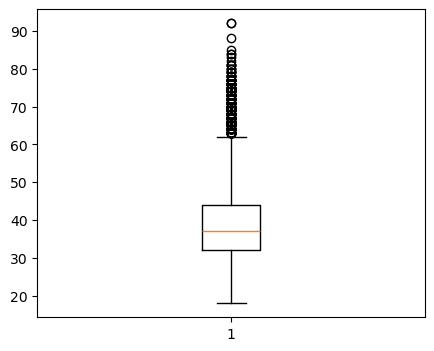

In [ ]:
plt.figure(figsize=(5, 4)) ##here figsize is the size of plot with width, height in inches.
plt.boxplot(x = df['age'])

In [7]:
age = df['age'].to_list() ##converting the 'age' column to a list so that we can use it to calculate the interquartile range (IQR) and identify the outliers.

In [8]:
Q1 = np.percentile(age , 25, interpolation = 'midpoint') ##calculating the first quartile (Q1) of the 'age' column. The 25th percentile is the value below which 25% of the data falls. The interpolation parameter is used to specify how to calculate the percentile when the desired percentile lies between two data points. In this case, we are using 'midpoint' which means that we will take the average of the two data points that lie on either side of the desired percentile.
Q2 = np.percentile(age , 50, interpolation = 'midpoint') ##calculating the second quartile (Q2) of the 'age' column. The 50th percentile is the value below which 50% of the data falls. This is also known as the median of the data.
Q3 = np.percentile(age , 75, interpolation = 'midpoint') ##calculating the third quartile (Q3) of the 'age' column. The 75th percentile is the value below which 75% of the data falls.

In [9]:
IQR = Q3 - Q1 ##calculating the interquartile range (IQR) of the 'age' column. The IQR is the difference between the third quartile (Q3) and the first quartile (Q1). It is a measure of the spread of the data and is used to identify outliers.

In [11]:
print("old age outliers are")
print("minimum:",Q1 - 1.5*IQR) ##calculating the lower bound for identifying outliers in the 'age' column. Any value below this bound is considered an outlier.
print("maximum:",Q3 + 1.5*IQR) ##calculating the upper bound for identifying outliers in the 'age' column. Any value above this bound is considered an outlier.

old age outliers are
minimum: 14.0
maximum: 62.0


In [13]:
outliers_age = []
for i in age:
    if i> Q3 + 1.5*IQR or i < Q1 - 1.5*IQR:
        outliers_age.append(i)
outliers_age ##this is the list of outliers in the 'age' column. We can see that there are 162 outliers in the 'age' column. We can remove these outliers from the data to improve the performance of our model. We will discuss how to remove outliers in the next section.    

[66,
 75,
 65,
 73,
 65,
 72,
 67,
 67,
 79,
 80,
 68,
 75,
 66,
 66,
 70,
 63,
 72,
 64,
 64,
 70,
 67,
 82,
 63,
 69,
 65,
 69,
 64,
 65,
 74,
 67,
 66,
 67,
 63,
 70,
 71,
 72,
 67,
 74,
 76,
 66,
 63,
 66,
 68,
 67,
 63,
 71,
 66,
 69,
 73,
 65,
 66,
 64,
 69,
 64,
 77,
 74,
 65,
 70,
 67,
 69,
 67,
 74,
 69,
 74,
 74,
 64,
 63,
 63,
 70,
 74,
 65,
 72,
 77,
 66,
 65,
 74,
 88,
 63,
 71,
 63,
 64,
 67,
 70,
 68,
 72,
 71,
 66,
 75,
 67,
 73,
 69,
 76,
 63,
 85,
 67,
 74,
 76,
 66,
 69,
 66,
 72,
 63,
 71,
 63,
 74,
 67,
 72,
 72,
 66,
 84,
 71,
 66,
 63,
 74,
 69,
 84,
 67,
 64,
 68,
 66,
 77,
 70,
 67,
 79,
 67,
 76,
 73,
 66,
 67,
 64,
 73,
 76,
 72,
 64,
 71,
 63,
 70,
 65,
 66,
 65,
 80,
 66,
 63,
 63,
 63,
 63,
 66,
 74,
 69,
 63,
 64,
 76,
 75,
 68,
 69,
 77,
 64,
 66,
 74,
 71,
 67,
 68,
 64,
 68,
 70,
 64,
 75,
 66,
 64,
 78,
 65,
 74,
 64,
 64,
 71,
 77,
 79,
 70,
 81,
 64,
 68,
 68,
 63,
 79,
 66,
 64,
 70,
 69,
 71,
 72,
 66,
 68,
 63,
 71,
 72,
 72,
 64,
 78,
 75,
 65,


In [14]:
df[df['age'].isin(outliers_age)] ##this will give us the rows of the data where the 'age' column has outliers. We can see that there are 162 rows in the data where the 'age' column has outliers. We can remove these rows from the data to improve the performance of our model. We will discuss how to remove outliers in the next section.

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
58,15623944,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,15805254,652,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,15804919,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,15589975,646,France,Female,73,6,97259.25,1,0,1,104719.66,0
181,15789669,510,France,Male,65,2,0.00,2,1,1,48071.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9753,15705174,656,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,15777067,445,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,15814690,595,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,15704795,521,France,Female,77,6,0.00,2,1,1,49054.10,0


In [15]:
df = df[~df['age'].isin(outliers_age)] ##this will remove the rows of the data where the 'age' column has outliers. We can see that there are 9838 rows in the data after removing the outliers in the 'age' column. We can check the shape of the data to confirm that the outliers have been removed.

### CreditScore

{'whiskers': [<matplotlib.lines.Line2D at 0x1fca22d2600>,
 'caps': [<matplotlib.lines.Line2D at 0x1fca22d2ba0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fca22d2360>],
 'medians': [<matplotlib.lines.Line2D at 0x1fca22d3170>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fca22d3440>],
 'means': []}

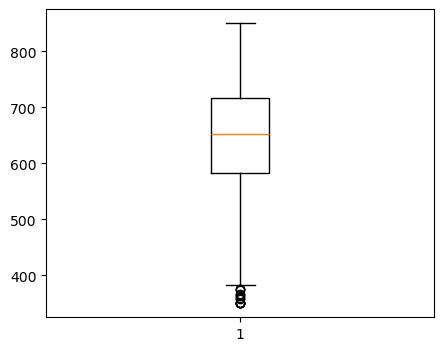

In [16]:
plt.figure(figsize=(5, 4)) ##here figsize is the size of plot with width, height in inches.
plt.boxplot(x = df['credit_score']) ##we can see that there are no outliers in the 'credit_score' column after removing the outliers in the 'age' column. This is because the 'credit_score' column is not affected by the outliers in the 'age' column. We can also see that the distribution of the 'credit_score' column is more normal after removing the outliers in the 'age' column.

In [17]:
credit = df['credit_score'].to_list()

In [18]:
Q1 = np.percentile(credit , 25 , interpolation = 'midpoint')
Q2 = np.percentile(credit , 50 , interpolation = 'midpoint')
Q3 = np.percentile(credit , 75 , interpolation = 'midpoint')

In [19]:
IQR = Q3-Q1 
print("Credit Score Mins:", Q1 - 1.5*IQR , "Credit Score Max:", Q3 + 1.5*IQR) ##we can see that there are no outliers in the 'credit_score' column since the minimum and maximum values for identifying outliers are outside the range of the 'credit_score' column. This is because the 'credit_score' column is not affected by the outliers in the 'age' column. We can also see that the distribution of the 'credit_score' column is more normal after removing the outliers in the 'age' column.

Credit Score Mins: 382.0 Credit Score Max: 918.0


In [20]:
outliers_credit = []
for i in credit:
    if i> Q3 + 1.5*IQR or i < Q1 - 1.5*IQR:
        outliers_credit.append(i)
outliers_credit

[376, 376, 363, 359, 350, 350, 358, 351, 365, 367, 350, 350, 373, 350]

In [21]:
df[df['credit_score'].isin(outliers_credit)] ##this will give us the rows of the data where the 'credit_score' column has outliers. We can see that there are no rows in the data where the 'credit_score' column has outliers. This is because the 'credit_score' column is not affected by the outliers in the 'age' column. We can also see that the distribution of the 'credit_score' column is more normal after removing the outliers in the 'age' column.

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,15804586,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,15779947,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,15612494,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,15685372,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,15758813,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,15692416,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,15679249,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,15597896,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,15791533,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


### outliers_credit have relationship with churn , also less , so untouched

### Balance ###

{'whiskers': [<matplotlib.lines.Line2D at 0x1fca2b63680>,
 'caps': [<matplotlib.lines.Line2D at 0x1fca2b63c20>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fca2b63350>],
 'medians': [<matplotlib.lines.Line2D at 0x1fca2b8c080>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fca2b8c350>],
 'means': []}

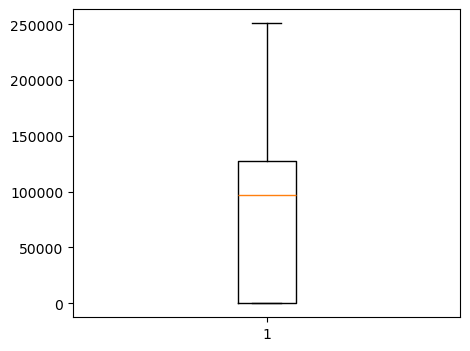

In [27]:
plt.figure(figsize=(5, 4)) 
plt.boxplot(x = df['balance']) 

In [22]:
balance = df['balance'].to_list()


In [23]:
Q1 = np.percentile(balance , 25 , interpolation = 'midpoint')
Q2 = np.percentile(balance , 50 , interpolation = 'midpoint')
Q3 = np.percentile(balance , 75 , interpolation = 'midpoint')
IQR = Q3-Q1
print("Balance Mins:", Q1 - 1.5*IQR , "Balance Max:", Q3 + 1.5*IQR)

Balance Mins: -191490.69 Balance Max: 319151.15


In [24]:
outliers_balance = []
for i in balance:
    if i> Q3 + 1.5*IQR or i < Q1 - 1.5*IQR:
        outliers_balance.append(i)
outliers_balance

[]

In [25]:
df[df['balance'].isin(outliers_balance)] ##this will give us the rows of the data where the 'balance' column has outliers. We can see that there are 1704 rows in the data where the 'balance' column has outliers. We can remove these rows from the data to improve the performance of our model. We will discuss how to remove outliers in the next section.

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


### Estimated Salary ###

{'whiskers': [<matplotlib.lines.Line2D at 0x1fca2bd1c10>,
 'caps': [<matplotlib.lines.Line2D at 0x1fca2bd2180>,
 'boxes': [<matplotlib.lines.Line2D at 0x1fca2bd1910>],
 'medians': [<matplotlib.lines.Line2D at 0x1fca2bd2600>],
 'fliers': [<matplotlib.lines.Line2D at 0x1fca2bd28d0>],
 'means': []}

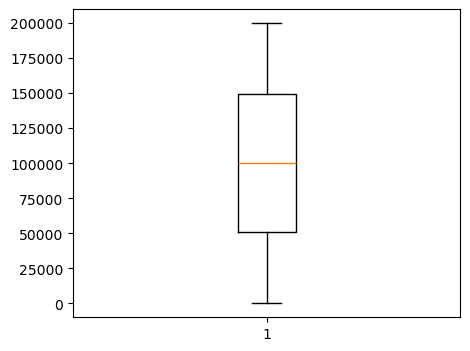

In [28]:
plt.figure(figsize=(5, 4)) 
plt.boxplot(x = df['estimated_salary']) 

In [30]:
salary = df['estimated_salary'].to_list()

In [31]:
Q1 = np.percentile(salary , 25 , interpolation = 'midpoint')
Q2 = np.percentile(salary , 50 , interpolation = 'midpoint')
Q3 = np.percentile(salary , 75 , interpolation = 'midpoint')
IQR = Q3-Q1
print("Salary Mins:", Q1 - 1.5*IQR , "Salary Max:", Q3 + 1.5*IQR)

Salary Mins: -96405.24500000001 Salary Max: 296977.115


In [34]:
outliers_salary = []
for i in salary:
    if i> Q3 + 1.5*IQR or i < Q1 - 1.5*IQR:
        outliers_salary.append(i)
outliers_salary

[]

In [35]:
salary = df['estimated_salary'].to_list()
Q1 = np.percentile(salary, 25, interpolation='midpoint')
Q3 = np.percentile(salary, 75, interpolation='midpoint')
IQR = Q3 - Q1
outliers_salary = [x for x in salary if x > Q3 + 1.5 * IQR or x < Q1 - 1.5 * IQR]
df[df['estimated_salary'].isin(outliers_salary)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [36]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [37]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

### VISUALISATIONS ###

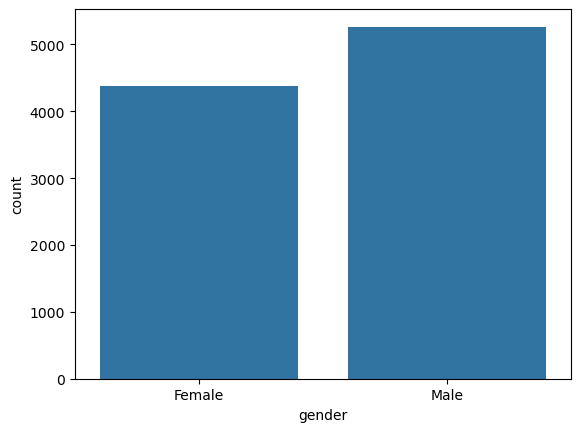

In [38]:
sns.countplot(data=df, x='gender')
plt.show()

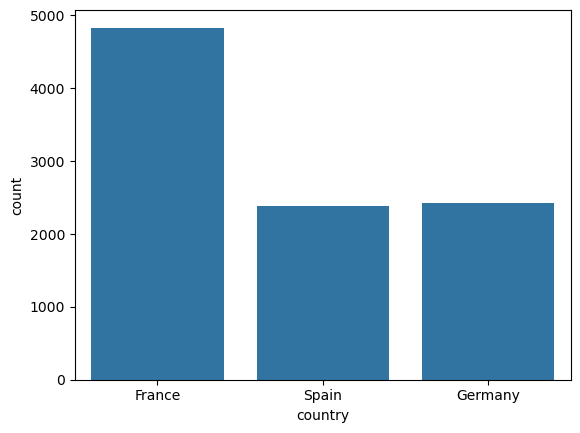

In [40]:
sns.countplot(data=df, x='country')
plt.show()

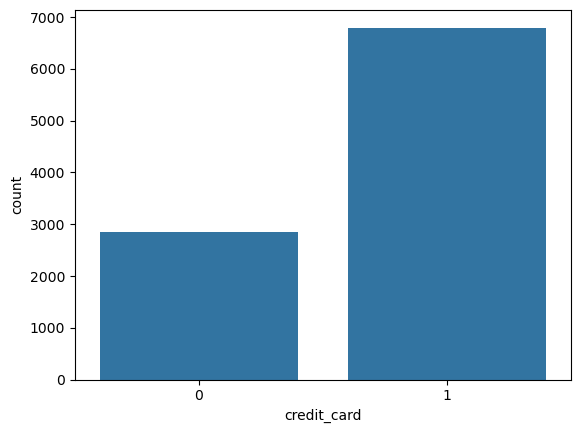

In [41]:
sns.countplot(data=df, x='credit_card')
plt.show()

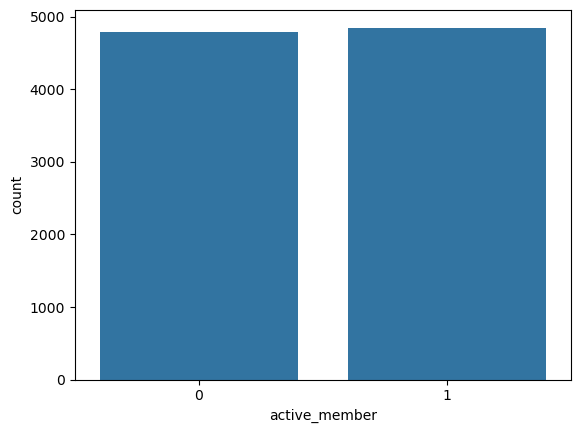

In [42]:
sns.countplot(data=df, x='active_member')
plt.show()

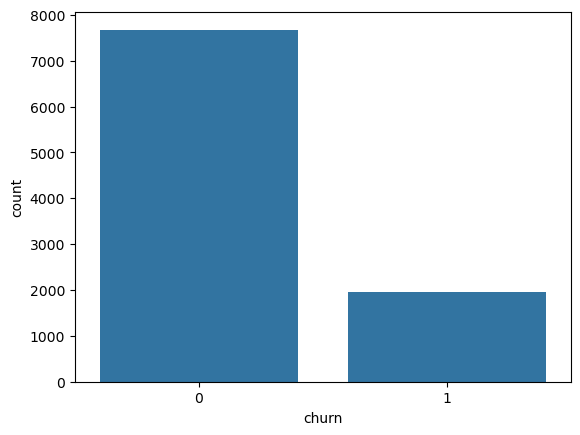

In [43]:
sns.countplot(data=df, x='churn')
plt.show()

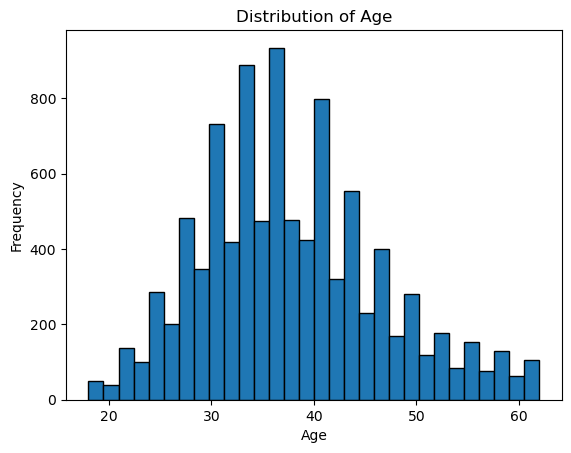

In [45]:
### histogram of age , showing distribution of age of customers
plt.hist(df['age'], bins=30, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')  
plt.show()

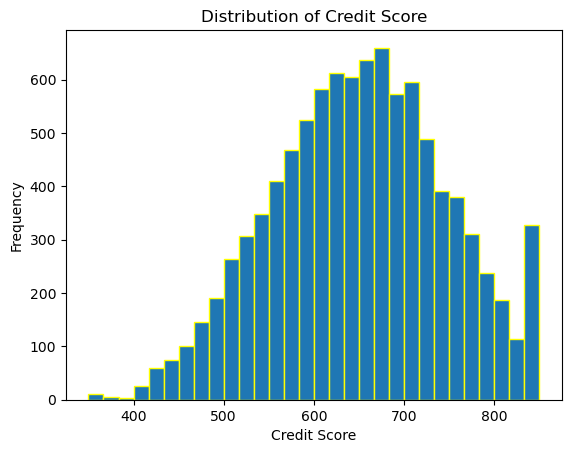

In [48]:
### histogram of credit score , showing distribution of credit scores of customers
plt.hist(df['credit_score'], bins=30, edgecolor='yellow')
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')  
plt.show()

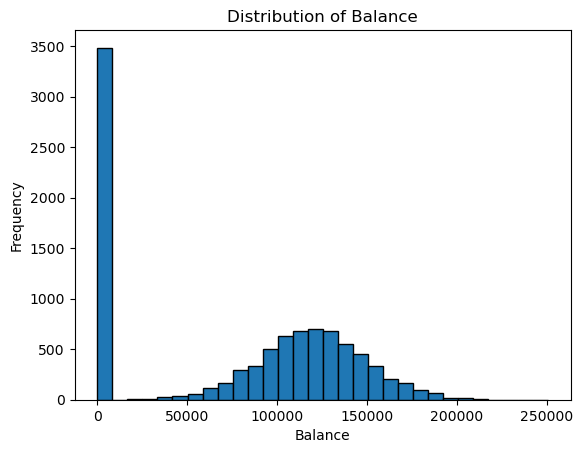

In [49]:
### histogram of Balance , showing distribution of balance of customers
plt.hist(df['balance'], bins=30, edgecolor='black')
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')  
plt.show()

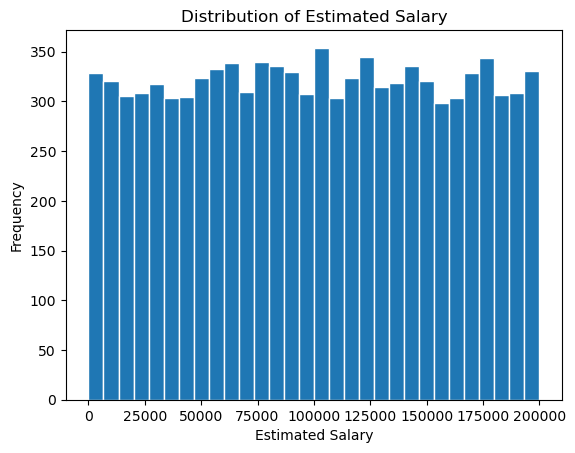

In [50]:
### histogram of estimated salary , showing distribution of estimated salary of customers
plt.hist(df['estimated_salary'], bins=30, edgecolor='white')
plt.title('Distribution of Estimated Salary')
plt.xlabel('Estimated Salary')
plt.ylabel('Frequency')  
plt.show()

### Comparing the imp fields with the Target

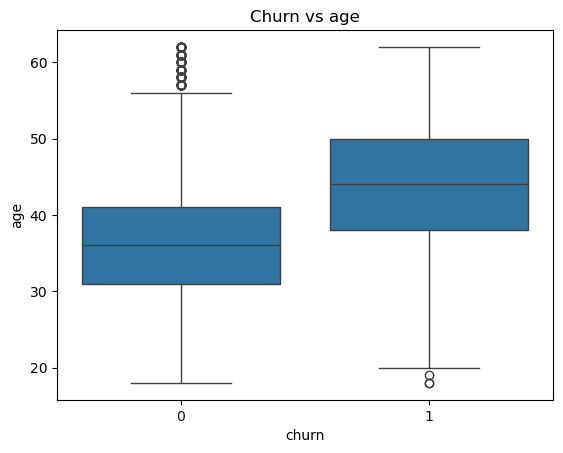

In [53]:
sns.boxplot( x = 'churn' , y = 'age' , data = df)
plt.title('Churn vs age')
plt.show()

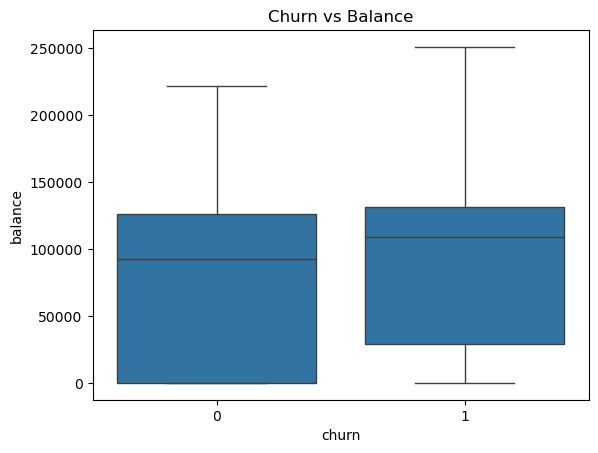

In [54]:
sns.boxplot( x = 'churn' , y = 'balance' , data = df)
plt.title('Churn vs Balance')
plt.show()

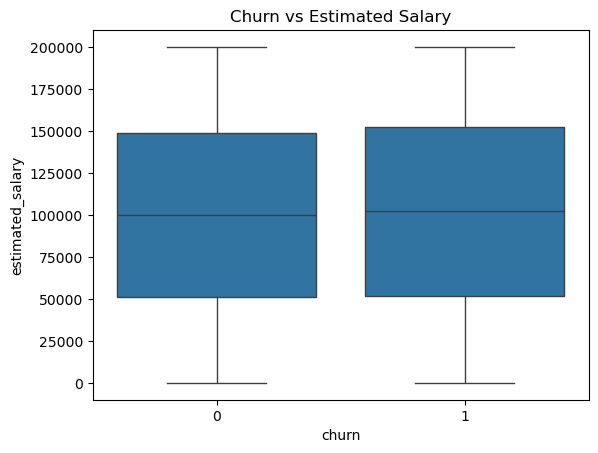

In [56]:
sns.boxplot( x = 'churn' , y = 'estimated_salary' , data = df)
plt.title('Churn vs Estimated Salary')
plt.show()

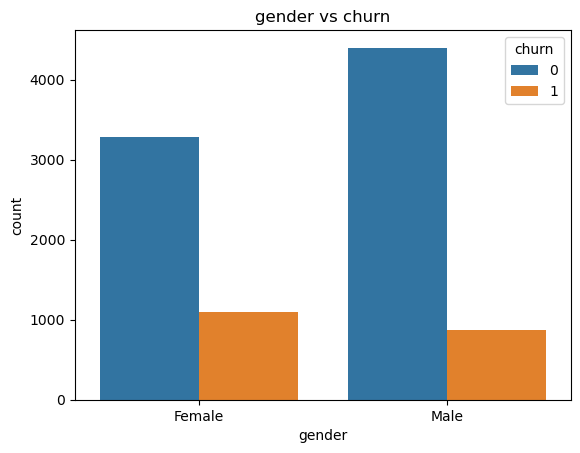

In [58]:
sns.countplot(data=df, x='gender', hue='churn')
plt.title("gender vs churn")
plt.show()

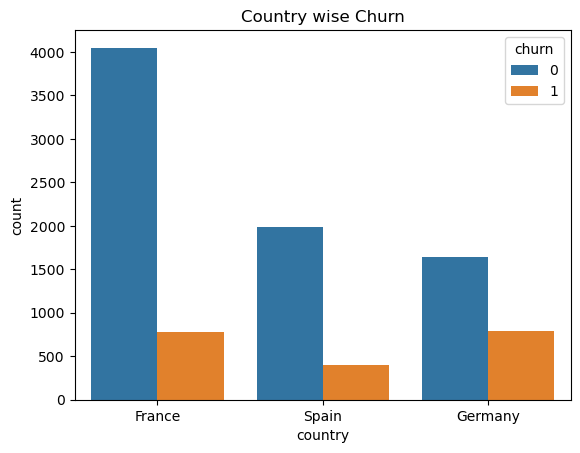

In [60]:
sns.countplot(data= df , x = 'country' , hue = 'churn')
plt.title("Country wise Churn")
plt.show()

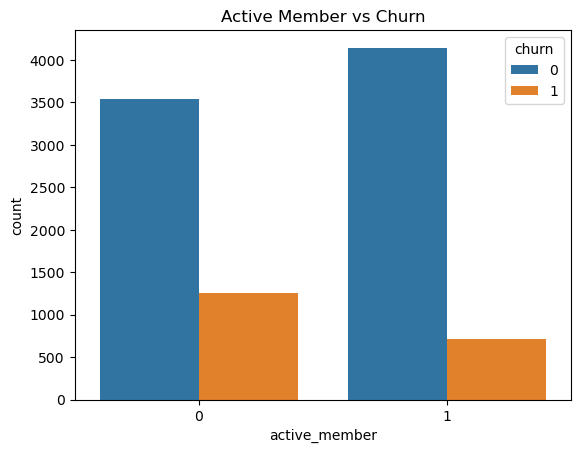

In [61]:
sns.countplot(data= df , x = 'active_member' , hue = 'churn')
plt.title("Active Member vs Churn")
plt.show()

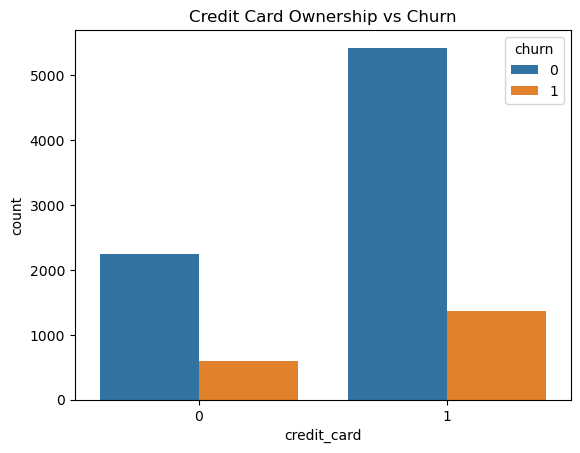

In [62]:
sns.countplot(data= df , x = 'credit_card' , hue = 'churn')
plt.title("Credit Card Ownership vs Churn")
plt.show()

In [64]:
df.drop(['row_number', 'customer_id', 'surname'], axis=1, inplace=True, errors='ignore') ##drop only existing columns; ignore missing ones

In [65]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
font_size = 15      ## this is the font size for the plots. We will use this font size for all the plots in this notebook to maintain consistency and improve the readability of the plots. We can adjust this font size as needed to make the plots more visually appealing and easier to understand.
plt.rcParams['axes.labelsize'] = font_size  ## this sets the font size for the axis labels in the plots. The 'axes.labelsize' parameter controls the font size of the labels on the x and y axes. By setting it to 'font_size', we are using the value of 'font_size' variable that we defined earlier to set the font size for the axis labels in all the plots in this notebook. This helps us maintain consistency in the appearance of our plots and makes them easier to read and understand.
plt.rcParams['axes.titlesize'] = font_size + 2   ## rcParams is a dictionary in matplotlib that contains the default settings for various plot elements. By setting the 'axes.titlesize' parameter to 'font_size + 2', we are increasing the font size of the plot titles by 2 points compared to the font size of the axis labels. This helps to make the plot titles stand out and be more visually appealing while maintaining consistency with the font size of the axis labels.
plt.rcParams['xtick.labelsize'] = font_size - 2   ## xtick label size is set to font_size - 2 to make them slightly smaller than the axis labels and titles, which helps to create a visual hierarchy in the plots and makes them easier to read and understand.
plt.rcParams['ytick.labelsize'] = font_size - 2   ## ytick label size is set to font_size - 2 to make them slightly smaller than the axis labels and titles, which helps to create a visual hierarchy in the plots and makes them easier to read and understand.
plt.rcParams['legend.fontsize'] = font_size - 2   ## legend font size is set to font_size - 2 to make it slightly smaller than the axis labels and titles, which helps to create a visual hierarchy in the plots and makes them easier to read and understand.

In [67]:
colors = ['green', 'pink' , 'red','cyan']

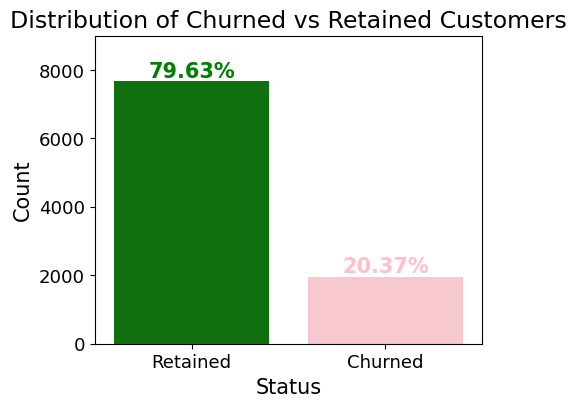

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))        ## this creates a figure and a set of subplots (in this case, just one subplot) with a specified size of 5 inches by 4 inches. The 'fig' variable represents the entire figure, while the 'ax' variable represents the specific subplot where we will plot our data. By using 'figsize=(5, 4)', we are setting the width of the figure to 5 inches and the height to 4 inches, which helps to create a visually appealing and well-proportioned plot for our data visualization.
sns.countplot(data=df, x ='churn' , palette=colors , ax = ax)  ## this creates a count plot using the seaborn library, where the x-axis represents the 'churn' variable and the y-axis represents the count of customers in each category (churned vs retained). The 'palette' parameter is used to specify the colors for the bars in the plot, and the 'ax' parameter is used to specify the subplot where we want to plot our data. This allows us to customize the appearance of our plot and make it more visually appealing and easier to understand.

for index, value in enumerate(df['churn'].value_counts()):
    label = '{}%'.format(round((value/df['churn'].shape[0])*100, 2))

    ax.annotate(label,
                xy=(index, value), 
                ha='center', 
                va='bottom',
                color = colors[index],
                fontweight='bold',
                size=font_size)
    
    ax.set_xticklabels(['Retained', 'Churned'])
    ax.set_title('Distribution of Churned vs Retained Customers')
    ax.set_xlabel('Status')
    ax.set_ylabel('Count')
    ax.set_ylim([0, 9000]);

In [74]:
categorical = ['country','gender','tenure','products','credit_card', 'active_member']

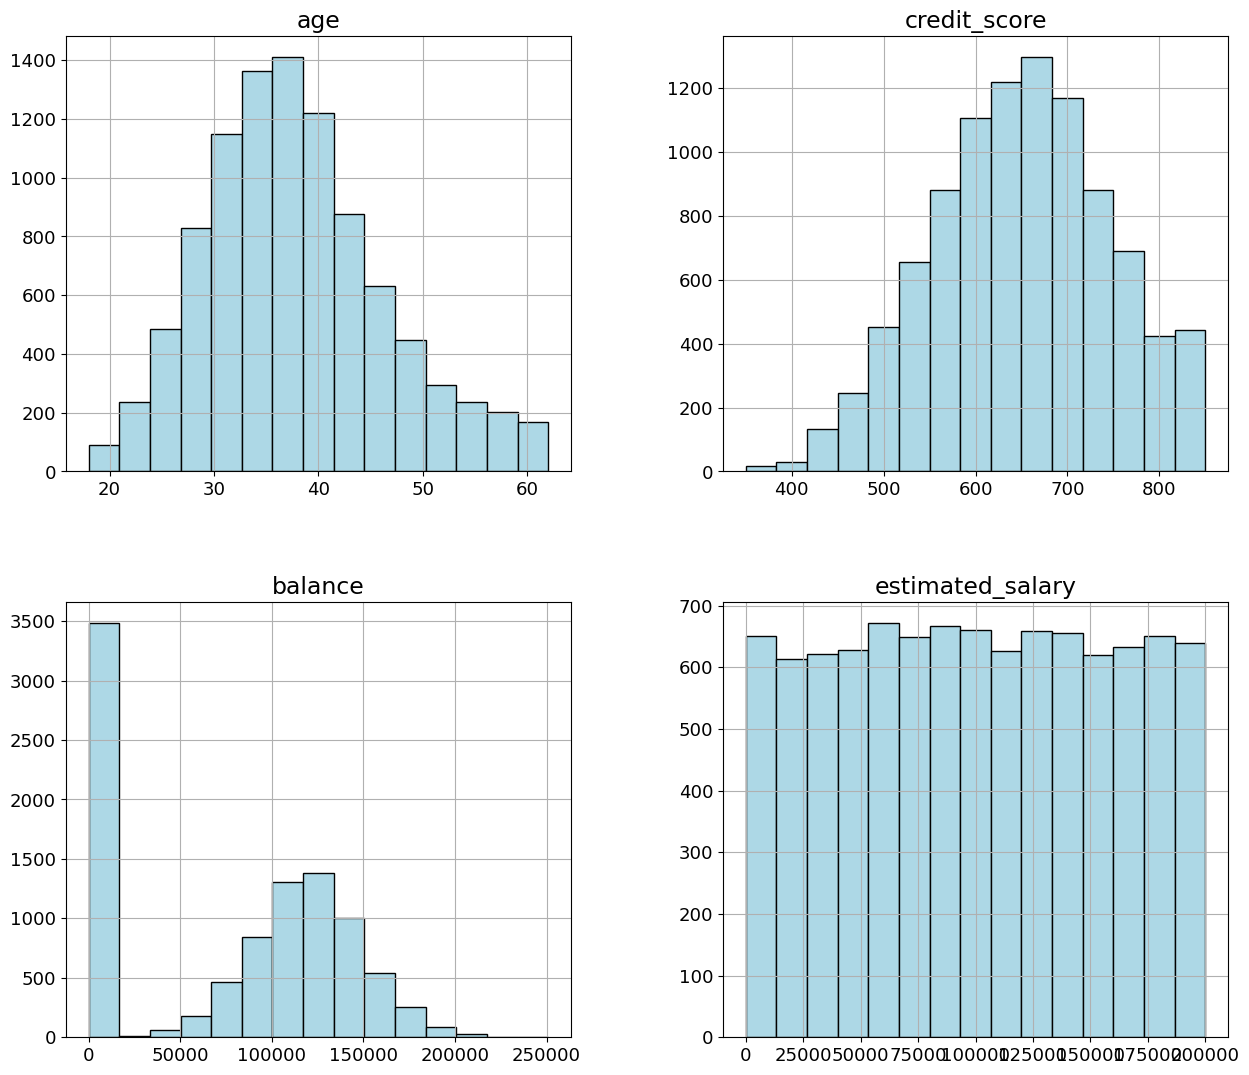

In [77]:
df[mulcols].hist(figsize=(15,13),bins=15,layout=(2,2),color='lightblue',edgecolor='black',linewidth=1.0);

In [78]:
df[mulcols].corr()

,age,credit_score,balance,estimated_salary
age,1.000000,-0.015989,0.041216,-0.004559
credit_score,-0.015989,1.000000,0.006396,-0.000493
balance,0.041216,0.006396,1.000000,0.010537
estimated_salary,-0.004559,-0.000493,0.010537,1.000000


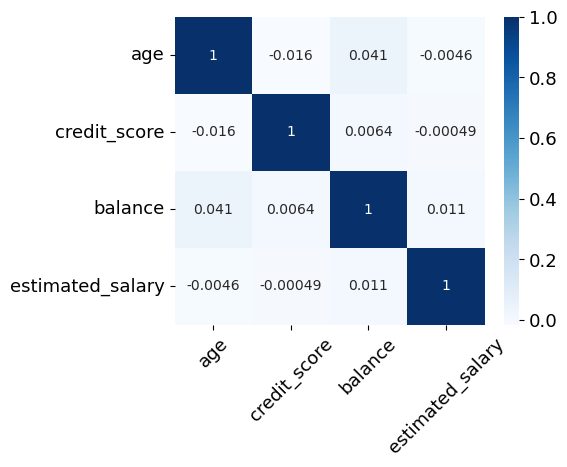

In [79]:
fig, ax = plt.subplots(figsize =(5,4))

sns.heatmap(df[mulcols].corr(),
            annot= True,
            annot_kws={'fontsize': 10},
            cmap='Blues',
            ax = ax)

ax.tick_params(axis='x', rotation = 45)
ax.tick_params(axis='y' , rotation = 360);

In [19]:
def plot_continuous(df, feature):  ## this function takes in a dataframe and a continuous feature as input and plots the distribution of the continuous feature for the churned and retained customers. This is important because it helps us understand how the continuous feature is distributed for the two groups of customers and if there are any differences in the distribution that can help us predict churn.

    df_func = df.copy() ##creating a copy of the original dataframe so that we can modify it without affecting the original dataframe. This is important because we want to keep the original dataframe intact for future reference and analysis. We will use this copy of the dataframe to plot the distribution of the continuous feature for the churned and retained customers.
    df_func['churn'] = df_func['churn'].astype('category') ##converting the 'churn' column to a categorical data type so that we can use it to plot the distribution of the continuous feature for the churned and retained customers.

    df_churned = df_func[df_func['churn'] == 1] ##creating a new dataframe that contains only the rows where the 'churn' column is equal to 1 (churned customers). This will allow us to plot the distribution of the continuous feature for the churned customers.
    df_retained = df_func[df_func['churn'] == 0] ##creating a new dataframe that contains only the rows where the 'churn' column is equal to 0 (retained customers). This will allow us to plot the distribution of the continuous feature for the retained customers.

    fig, (ax1, ax2) = plt.subplots(2, 
                                   figsize=(9, 7),
                                   sharex=True,
                                   gridspec_kw= {'height_ratios': [.7, .3]}) ##this creates a figure with two subplots (ax1 and ax2) arranged in one row and two columns. The figsize parameter specifies the size of the figure in inches. In this case, the width of the figure is 12 inches and the height is 5 inches. This allows us to plot the distribution of the continuous feature for both churned and retained customers side by side for easy comparison.
    
    colors = ['#1f77b4', '#ff7f0e'] ##this is a list of colors that we will use to plot the distribution of the continuous feature for the churned and retained customers. The first color in the list will be used for the churned customers and the second color will be used for the retained customers. This helps to visually differentiate between the two groups of customers in the plots.
    
    for sub_df, color, label in zip([df_retained ,df_churned], colors, ['Retained','Churned']):
        sns.histplot(data=sub_df,
                     x=feature,
                     bins = 15, 
                     alpha = 0.6,
                     edgecolor='firebrick',
                     kde=False, 
                     label=label,
                     color=color, 
                     ax=ax1) ##this creates a histogram plot with a kernel density estimate (KDE) overlay for the specified feature in the sub-dataframe (either churned or retained customers). The color parameter specifies the color of the bars in the histogram and the KDE line. The ax parameter specifies which subplot to plot on (either ax1 for churned customers or ax2 for retained customers). This allows us to visually compare the distribution of the continuous feature for both groups of customers.
        
    ax1.legend() ##this adds a legend to the first subplot (ax1) to differentiate between the churned and retained customers based on the colors used in the histogram. This helps to make the plot more informative and easier to understand.
    sns.boxplot(x = feature , y = 'churn', data = df_func, ax = ax2) ##this creates a box plot to visualize the distribution of the specified feature for the churned and retained customers. The x parameter specifies the feature to be plotted on the x-axis, the y parameter specifies the 'churn' column to be plotted on the y-axis, and the data parameter specifies the dataframe to be used for plotting. The ax parameter specifies which subplot to plot on (either ax1 for churned customers or ax2 for retained customers). This allows us to visually compare the distribution of the continuous feature for both groups of customers and identify any differences in their distributions.
    ax2.set_ylabel('') ##this removes the x-axis label from the second subplot (
    ax2.set_yticklabels(['Retained', 'Churned']) ##this sets the y-axis tick labels for the second subplot (ax2) to 'Retained' and 'Churned' to differentiate between the two groups of customers based on their churn status. This helps to make the plot more informative and easier to understand.
    plt.tight_layout()
    plt.show()

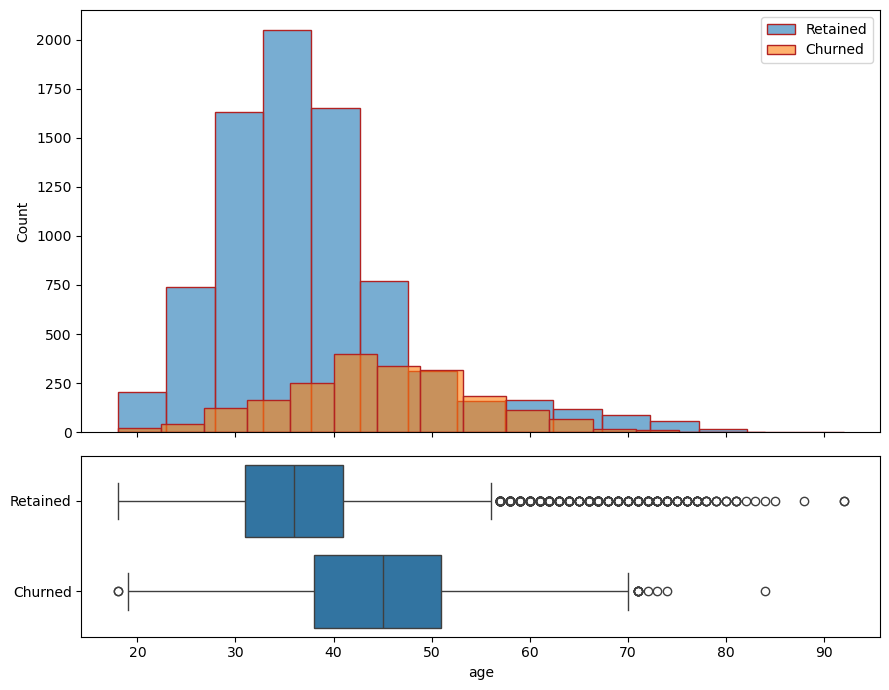

In [20]:
plot_continuous(df, 'age') ##this calls the plot_continuous function to plot the distribution of the 'age' feature for the churned and retained customers. This will help us understand how the age of the customers is distributed for both groups and if there are any differences in the distribution that can help us predict churn.

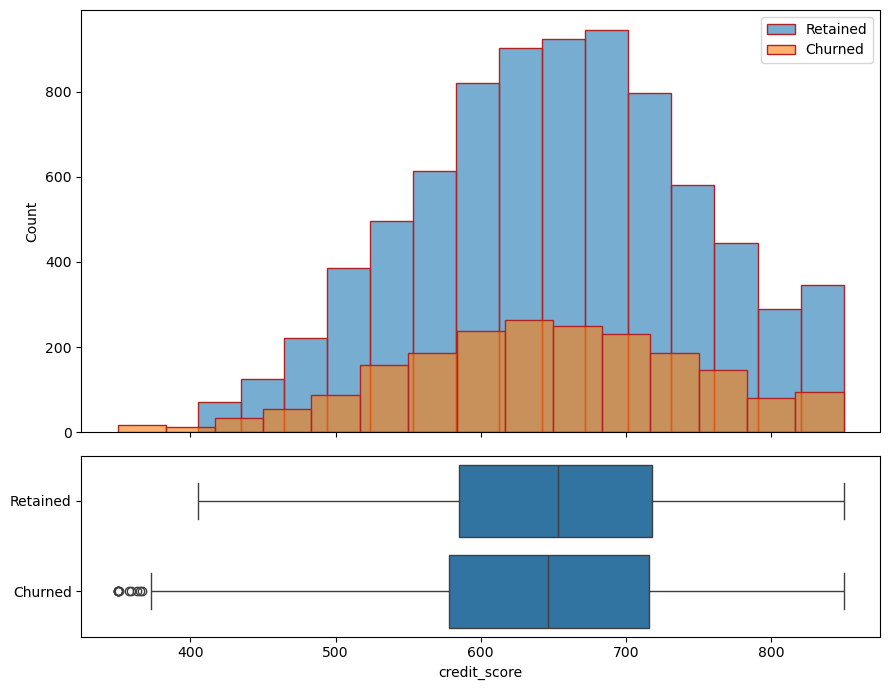

In [21]:
plot_continuous(df, 'credit_score') ##this calls the plot_continuous function to plot the distribution of the 'credit_score' feature for the churned and retained customers. This will help us understand how the credit score of the customers is distributed for both groups and if there are any differences in the distribution that can help us predict churn.

In [6]:
font_size = 16
plt.rcParams['axes.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size + 2
plt.rcParams['xtick.labelsize'] = font_size - 2
plt.rcParams['ytick.labelsize'] = font_size - 2
plt.rcParams['legend.fontsize'] = font_size - 2

colors_cat = ['cyan', 'steelblue', 'seagreen', 'black', 'darkorange', 'purple', 'firebrick', 'slategray', 'red', 'yellow', 'pink']

In [12]:
categorical = ['country', 'gender', 'tenure', 'products_number', 'credit_card', 'active_member']
print(categorical)


['country', 'gender', 'tenure', 'products_number', 'credit_card', 'active_member']


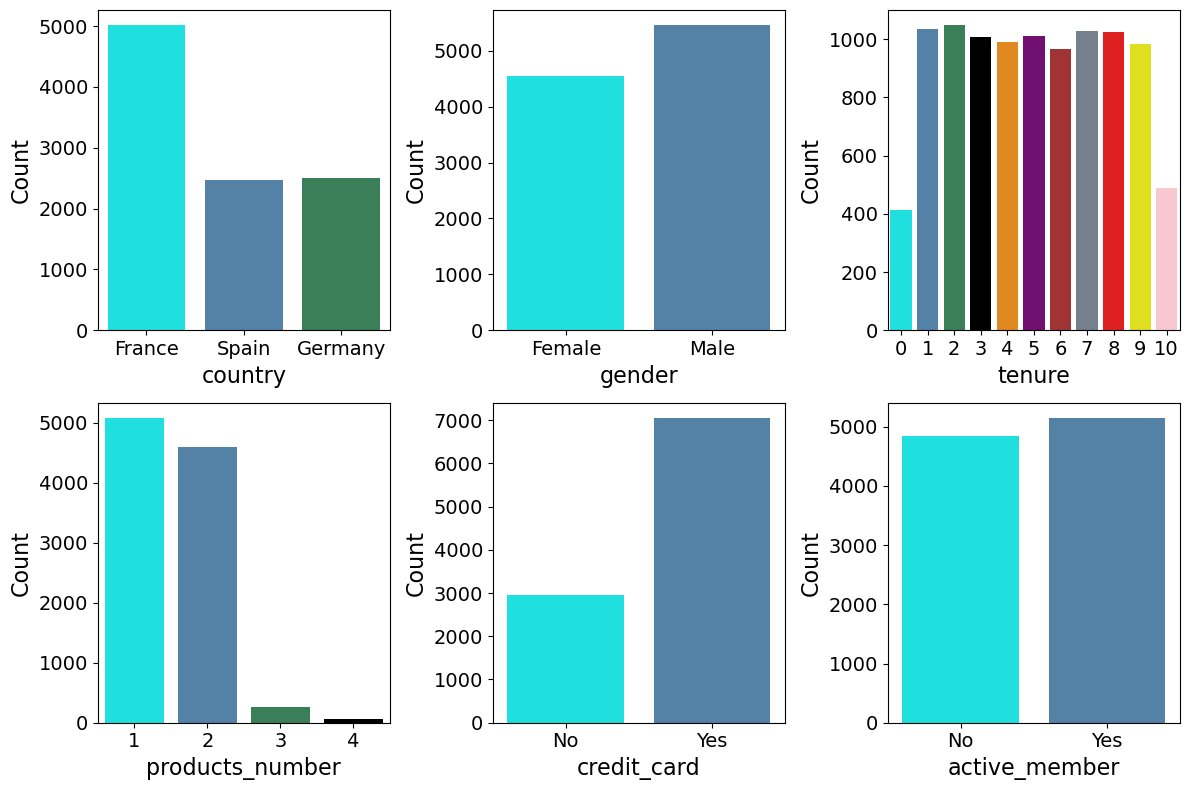

In [13]:
df_cat =  df[categorical]
fig, ax = plt.subplots(2, 3, figsize=(12, 8))

for index, column in  enumerate(df_cat.columns):

    plt.subplot(2, 3, index + 1)
    sns.countplot(x=column, data= df, palette= colors_cat)

    plt.ylabel('Count')
    if (column == 'credit_card' or column == 'active_member'):
        plt.xticks([0,1], ['No', 'Yes'])

plt.tight_layout();
        

In [18]:
def plot_categorical(feature):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x = feature,
                  hue = 'churn',
                  data = df,
                  palette = colors_cat,
                  ax= ax1)
    ax1.set_ylabel('Count')
    ax1.legend(labels = ['Retained', 'Churned'])

    sns.barplot(x = feature,
                y = 'churn',
                data = df,
                palette = colors_cat,
                ax=ax2)
    ax2.set_ylabel('Churn Rate')

    if (feature == 'credit_card' or feature == 'active_member'):
        ax1.set_xticklabels(['No', 'Yes'])
        ax2.set_xticklabels(['No', 'Yes'])

    plt.tight_layout();    

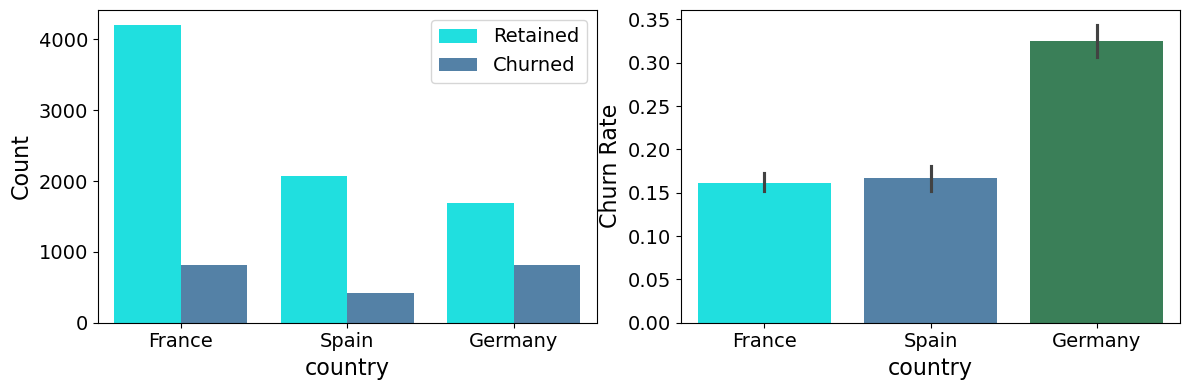

In [19]:
plot_categorical('country')

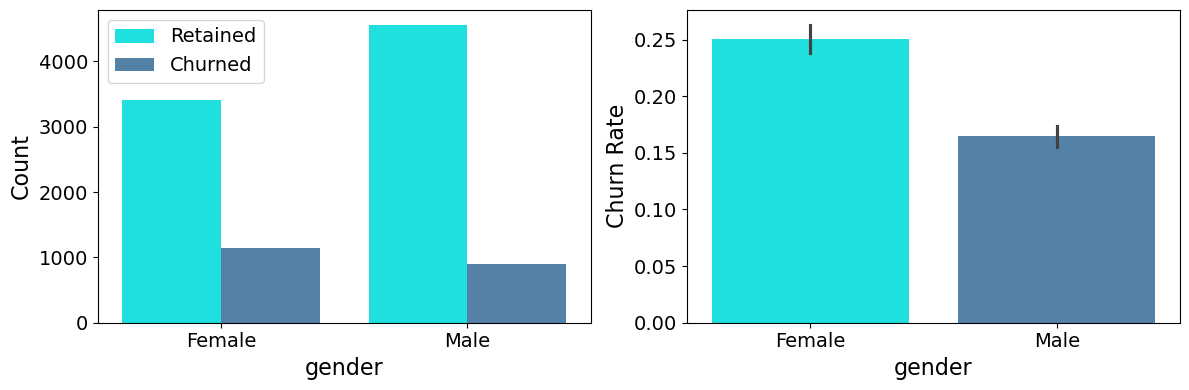

In [20]:
plot_categorical('gender')

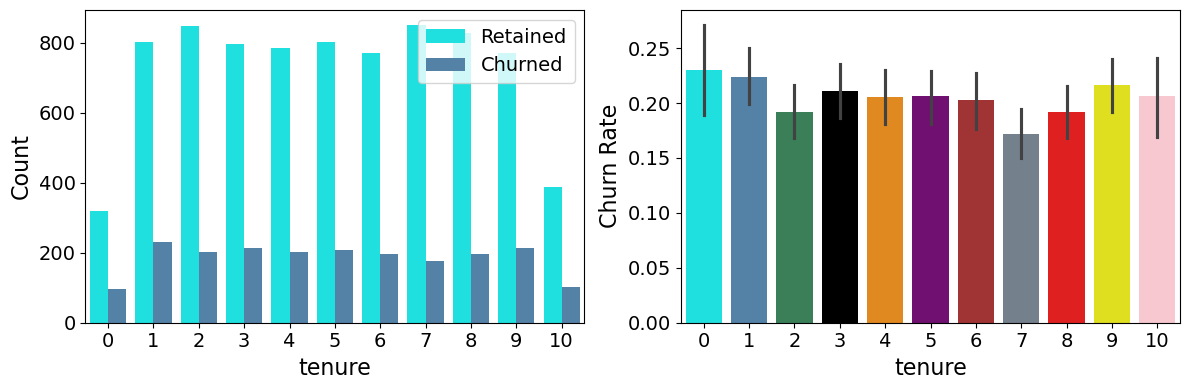

In [21]:
plot_categorical('tenure')

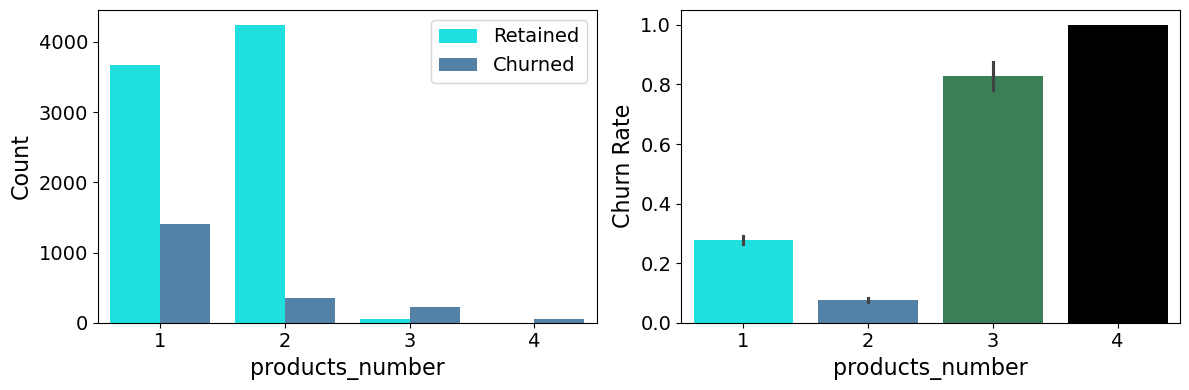

In [22]:
plot_categorical('products_number')

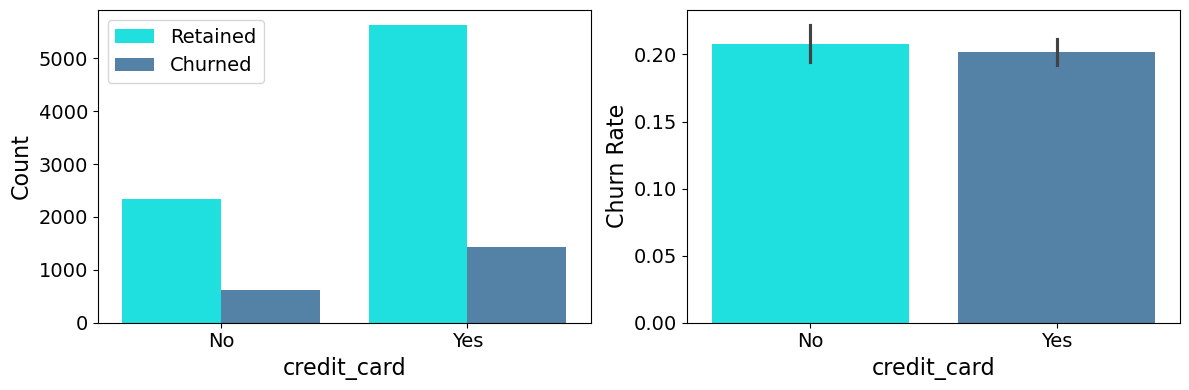

In [23]:
plot_categorical('credit_card')

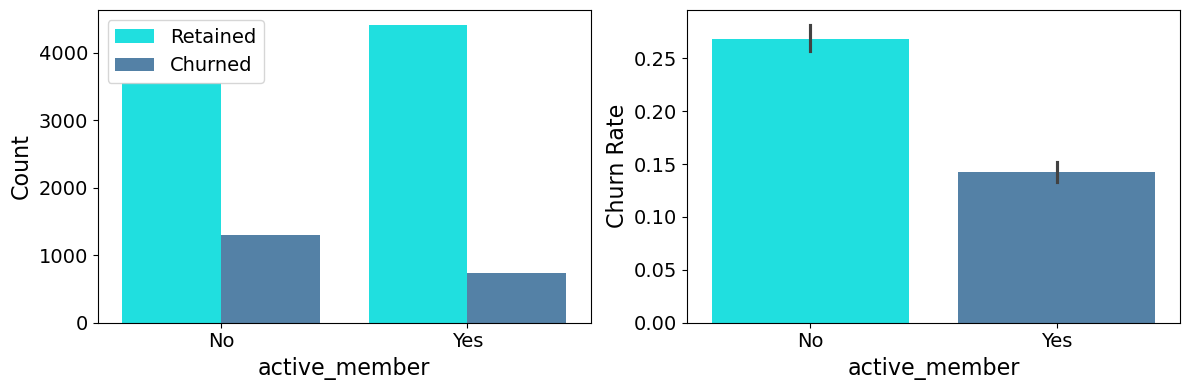

In [24]:
plot_categorical('active_member')

In [25]:
features_drop = ['tenure', 'credit_card',  'estimated_salary']

In [27]:
df = df.drop(features_drop, axis=1)

In [28]:
df.head()

,customer_id,credit_score,country,gender,age,balance,products_number,active_member,churn
0,15634602,619,France,Female,42,0.00,1,1,1
1,15647311,608,Spain,Female,41,83807.86,1,1,0
2,15619304,502,France,Female,42,159660.80,3,0,1
3,15701354,699,France,Female,39,0.00,2,0,0
4,15737888,850,Spain,Female,43,125510.82,1,1,0


In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
	df.drop(columns=['churn']),
	df['churn'],
	test_size=0.2,
	random_state=43,
	stratify=df['churn']
)

In [20]:
print("Original country values:")
print(df['country'].unique())
print("\nCountry value counts:")
print(df['country'].value_counts())

Original country values:
['France' 'Spain' 'Germany']

Country value counts:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [21]:
x_train.shape , y_train.shape , x_test.shape , y_test.shape

((8000, 11), (8000,), (2000, 11), (2000,))

In [22]:
y_test.value_counts()

churn
0    1593
1     407
Name: count, dtype: int64

In [23]:
df['gender'].value_counts()

gender
Male      5457
Female    4543
Name: count, dtype: int64

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [25]:
x_train['gender'].value_counts()

gender
Male      4388
Female    3612
Name: count, dtype: int64

In [26]:
x_train['gender'] = le.fit_transform(x_train['gender'])
x_test['gender'] = le.transform(x_test['gender'])
x_train['gender'].value_counts()

gender
1    4388
0    3612
Name: count, dtype: int64

In [27]:
def country_conversion(df):
    df['country'] = df['country'].map({
        'Germany' :1,
        'Spain' :0,
        'France' :0
    })
    return df

In [28]:
x_train = country_conversion(x_train)
x_test = country_conversion(x_test)


In [29]:
print("x_train country unique BEFORE conversion:")
x_train_backup = x_train.copy()
# Check what we have
print(df['country'].unique())  # Check original df

x_train country unique BEFORE conversion:
['France' 'Spain' 'Germany']


In [105]:
print(x_test['country'].unique())
print(x_test['country'].value_counts())

[nan]
Series([], Name: count, dtype: int64)


In [102]:
x_test = country_conversion(x_test)

In [103]:
x_test['country'].value_counts()

Series([], Name: count, dtype: int64)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scl_columns = ['credit_score', 'age', 'balance']
x_train[scl_columns] = scaler.fit_transform(x_train[scl_columns])
x_test[scl_columns] = scaler.transform(x_test[scl_columns])

In [104]:
x_test.describe()

,customer_id,credit_score,country,gender,age,balance,products_number,active_member
count,2.000000e+03,2000.000000,0.0,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.569129e+07,-0.026925,NaN,0.534500,0.009268,0.012441,1.530500,0.520500
std,7.266932e+04,1.017353,NaN,0.498933,1.013498,1.004490,0.590122,0.499705
min,1.556571e+07,-3.109504,NaN,0.000000,-1.994969,-1.225848,1.000000,0.000000
25%,1.562797e+07,-0.740092,NaN,0.000000,-0.660018,-1.225848,1.000000,0.000000
50%,1.569081e+07,0.004875,NaN,1.000000,-0.183251,0.341977,1.000000,1.000000
75%,1.575465e+07,0.687763,NaN,1.000000,0.484225,0.820433,2.000000,1.000000
max,1.581566e+07,2.063884,NaN,1.000000,4.393722,2.183006,4.000000,1.000000


In [117]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    df.drop(columns=['churn']),
    df['churn'],
    test_size=0.2,
    random_state=43,
    stratify=df['churn']
)

from sklearn.preprocessing import LabelEncoder

for col in x_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    le.fit(pd.concat([x_train[col], x_test[col]]))  # fit on both combined
    x_train[col] = le.transform(x_train[col])
    x_test[col] = le.transform(x_test[col])

# Drop the 'country' column as it contains NaN values that SMOTE cannot handle
x_train = x_train.drop('country', axis=1, errors='ignore')
x_test = x_test.drop('country', axis=1, errors='ignore')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scl_columns = ['credit_score', 'age', 'balance']
x_train[scl_columns] = scaler.fit_transform(x_train[scl_columns])
x_test[scl_columns] = scaler.transform(x_test[scl_columns])

over = SMOTE(sampling_strategy='auto', random_state=42)
x_train, y_train = over.fit_resample(x_train, y_train)

In [118]:
y_train.value_counts()

churn
0    6370
1    6370
Name: count, dtype: int64

### Choosing the Model ###

In [119]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [120]:
scoring_metric = 'accuracy'

In [124]:
clf_list = [
    ('Logistic Regression', LogisticRegression(random_state=43)),]

cv_base_mean, cv_std = [], []

for clf in clf_list:
    cv = cross_val_score(estimator= clf[1], X=x_train, y=y_train, cv=5, scoring=scoring_metric, n_jobs=-1)
    cv_base_mean.append(cv.mean())
    cv_std.append(cv.std())

print('Baseline Models (Recall):')

for i in range(len(clf_list)):
    print('  {}: {}'.format(clf_list[i][0], np.round(cv_base_mean[i], 2)))

Baseline Models (Recall):
  Logistic Regression: 0.75


In [125]:
clf_list = [
    ('Logistic Regression', LogisticRegression(random_state=43)),
    ('Decision Tree', DecisionTreeClassifier(random_state=43)),
    ('Random Forest', RandomForestClassifier(random_state=43))]

In [126]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import  confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, auc, roc_auc_score

In [128]:
lr = LogisticRegression(random_state=43)

param_grid = {
    'max_iter': [100],
    'penalty': ['l1', 'l2'],
    'C': [0.0001, 0.001 , 0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_clf = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, verbose=False, n_jobs=-1)

best_lr_clf = lr_clf.fit(x_train, y_train)

In [129]:
best_lr_clf.best_estimator_

LogisticRegression(C=1, penalty='l1', random_state=43, solver='liblinear')

In [130]:
lr_best = LogisticRegression(C=0.001, penalty='l1', random_state=43, solver='liblinear')

In [131]:
lr_best.fit(x_train, y_train)

LogisticRegression(C=0.001, penalty='l1', random_state=43, solver='liblinear')

In [132]:
y_train_lr_pred = lr_best.predict(x_train)

In [133]:
print(classification_report(y_train, y_train_lr_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73      6370
           1       0.74      0.70      0.72      6370

    accuracy                           0.73     12740
   macro avg       0.73      0.73      0.73     12740
weighted avg       0.73      0.73      0.73     12740



In [134]:
y_test_lr_pred = lr_best.predict(x_test)
print(classification_report(y_test, y_test_lr_pred))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1593
           1       0.41      0.68      0.51       407

    accuracy                           0.73      2000
   macro avg       0.66      0.71      0.66      2000
weighted avg       0.80      0.73      0.76      2000



In [5]:
!pip install xgboost  lightgbm 

In [6]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
!pip install xgboost  

In [31]:
from sklearn.model_selection import GridSearchCV

#find the best parameters using gridsearchcv

rf = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [2, 3, 5],
    'max_features': ['auto', 'sqrt'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

rf_clf = GridSearchCV(estimator=rf, 
                      param_grid=param_grid,
                       scoring= 'f1',
                        cv=5, verbose=False, n_jobs=-1)  

best_rf_clf = rf_clf.fit(x_train, y_train)

In [32]:
best_rf_clf.best_estimator_

RandomForestClassifier(max_depth=6, min_samples_leaf=3)

In [33]:
best_rf_clf.best_params_

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 100}

In [34]:
rfc = RandomForestClassifier(bootstrap= False , max_depth=6 , min_samples_leaf=2, min_samples_split=3, n_estimators=150)

In [35]:
rfc.fit(x_train, y_train)

RandomForestClassifier(bootstrap=False, max_depth=6, min_samples_leaf=2,
                       min_samples_split=3, n_estimators=150)

In [36]:
y_train_pred_rf = rfc.predict(x_train)

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_train, y_train_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      6370
           1       0.89      0.37      0.52      1630

    accuracy                           0.86      8000
   macro avg       0.87      0.68      0.72      8000
weighted avg       0.87      0.86      0.84      8000



In [39]:
y_test_pred_rf = rfc.predict(x_test)

In [40]:
print(classification_report(y_train, y_train_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      6370
           1       0.89      0.37      0.52      1630

    accuracy                           0.86      8000
   macro avg       0.87      0.68      0.72      8000
weighted avg       0.87      0.86      0.84      8000



In [41]:
gbc = GradientBoostingClassifier()

param_grid = {
    'n_estimators': [600],
    'learning_rate': [0.001, 0.01],
    'max_depth': [3, 4, 5],
    'min_samples_split': [5, 7, 10],
    'min_samples_leaf': [3, 5, 7],
    'max_features': ['auto', 'log2', None],
    'subsample': [0.66, 0.75],
    'n_iter_no_change': [20],
    'validation_fraction': [0.2],
    'tol': [0.01]


}

gbc_clf = GridSearchCV(estimator=gbc,
                        param_grid=param_grid,
                         scoring= 'f1',
                            cv=5, verbose=False, n_jobs=-1) 
best_gbc_clf = gbc_clf.fit(x_train, y_train)

In [42]:
best_gbc_clf.best_params_

{'learning_rate': 0.01,
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 5,
 'min_samples_split': 7,
 'n_estimators': 600,
 'n_iter_no_change': 20,
 'subsample': 0.66,
 'tol': 0.01,
 'validation_fraction': 0.2}

In [43]:
best_gbc_clf.best_estimator_

GradientBoostingClassifier(learning_rate=0.01, max_depth=5, min_samples_leaf=5,
                           min_samples_split=7, n_estimators=600,
                           n_iter_no_change=20, subsample=0.66, tol=0.01,
                           validation_fraction=0.2)

In [44]:
gbc = GradientBoostingClassifier(learning_rate=0.01, max_depth=5, min_samples_leaf=3, min_samples_split=7, n_estimators=600, n_iter_no_change=20, subsample=0.66, tol=0.01, validation_fraction=0.2)